In [1]:
from pathlib import Path
from collections import defaultdict
import hashlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("Imports successful.")

Imports successful.


In [2]:
INPUT_ROOT = Path("/kaggle/input")

dataset_candidates = [
    p for p in INPUT_ROOT.rglob("kaggle_dataset")
    if p.is_dir()
]

print("Dataset candidates:")

for p in dataset_candidates:
    print(p)

if not dataset_candidates:
    raise FileNotFoundError(
        "kaggle_dataset not found. "
        "Attach GeoSigLIP DCID-7 Lithology Dataset."
    )

DATA_ROOT = dataset_candidates[0]

print("\nUsing dataset:")
print(DATA_ROOT)

Dataset candidates:
/kaggle/input/datasets/utkarshrode/geosiglip-dcid-7-lithology-dataset/kaggle_dataset

Using dataset:
/kaggle/input/datasets/utkarshrode/geosiglip-dcid-7-lithology-dataset/kaggle_dataset


In [3]:
train_df = pd.read_csv(
    DATA_ROOT / "train.csv"
)

val_df = pd.read_csv(
    DATA_ROOT / "validation.csv"
)

test_df = pd.read_csv(
    DATA_ROOT / "test.csv"
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nColumns:")
print(train_df.columns.tolist())

Train: 2450
Validation: 1050
Test: 1750

Columns:
['image_path', 'label']


In [4]:
def resolve_paths(df):
    df = df.copy()

    df["resolved_path"] = df[
        "image_path"
    ].apply(
        lambda x: DATA_ROOT / str(x)
    )

    return df


train_df = resolve_paths(train_df)
val_df = resolve_paths(val_df)
test_df = resolve_paths(test_df)


for name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:

    missing = (
        ~df["resolved_path"]
        .apply(Path.exists)
    )

    print(
        f"{name:12s} missing: {missing.sum()}"
    )

    if missing.any():
        raise FileNotFoundError(
            f"Missing images in {name} split."
        )

print("\nAll images exist.")

train        missing: 0
validation   missing: 0
test         missing: 0

All images exist.


In [5]:
print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    print(f"\n{name}")

    counts = (
        df["label"]
        .value_counts()
        .sort_index()
    )

    print(counts)

CLASS DISTRIBUTION

Train
label
Basalt             350
Granite            350
Gray siltstone     350
Light sandstone    350
Marble             350
Mudstone           350
Red sandstone      350
Name: count, dtype: int64

Validation
label
Basalt             150
Granite            150
Gray siltstone     150
Light sandstone    150
Marble             150
Mudstone           150
Red sandstone      150
Name: count, dtype: int64

Test
label
Basalt             250
Granite            250
Gray siltstone     250
Light sandstone    250
Marble             250
Mudstone           250
Red sandstone      250
Name: count, dtype: int64


In [6]:
train_paths = set(
    train_df["resolved_path"].astype(str)
)

val_paths = set(
    val_df["resolved_path"].astype(str)
)

test_paths = set(
    test_df["resolved_path"].astype(str)
)

train_val = train_paths & val_paths
train_test = train_paths & test_paths
val_test = val_paths & test_paths

print("Exact path overlap:")
print(
    "Train ∩ Validation:",
    len(train_val)
)

print(
    "Train ∩ Test:",
    len(train_test)
)

print(
    "Validation ∩ Test:",
    len(val_test)
)

if (
    len(train_val) == 0
    and len(train_test) == 0
    and len(val_test) == 0
):
    print("\nNo path overlap detected.")
else:
    print(
        "\nWARNING: Path overlap detected."
    )

Exact path overlap:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

No path overlap detected.


In [7]:
def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


def add_hashes(df):

    df = df.copy()

    hashes = []

    start = time.time()

    for i, path in enumerate(
        df["resolved_path"]
    ):

        hashes.append(
            sha256_file(path)
        )

        if (i + 1) % 500 == 0:
            print(
                f"Processed {i + 1}/{len(df)}"
            )

    df["sha256"] = hashes

    print(
        "Time:",
        round(
            (time.time() - start) / 60,
            2
        ),
        "minutes"
    )

    return df


train_df = add_hashes(train_df)
val_df = add_hashes(val_df)
test_df = add_hashes(test_df)

print("\nHashing complete.")

Processed 500/2450
Processed 1000/2450
Processed 1500/2450
Processed 2000/2450
Time: 0.19 minutes
Processed 500/1050
Processed 1000/1050
Time: 0.09 minutes
Processed 500/1750
Processed 1000/1750
Processed 1500/1750
Time: 0.13 minutes

Hashing complete.


In [8]:
hash_to_splits = defaultdict(list)

for split_name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:

    for h in df["sha256"]:

        hash_to_splits[h].append(
            split_name
        )


cross_split_duplicates = []

for image_hash, splits in (
    hash_to_splits.items()
):

    unique_splits = sorted(
        set(splits)
    )

    if len(unique_splits) > 1:

        cross_split_duplicates.append({
            "sha256": image_hash,
            "splits": ", ".join(
                unique_splits
            ),
            "occurrences": len(splits)
        })


duplicate_df = pd.DataFrame(
    cross_split_duplicates
)

print("=" * 60)
print("CROSS-SPLIT EXACT DUPLICATES")
print("=" * 60)

print(
    "Duplicate hashes:",
    len(duplicate_df)
)

if len(duplicate_df) == 0:

    print(
        "No exact duplicate images "
        "were found across splits."
    )

else:

    display(
        duplicate_df.head(20)
    )

CROSS-SPLIT EXACT DUPLICATES
Duplicate hashes: 0
No exact duplicate images were found across splits.


In [9]:
all_df = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="validation"),
        test_df.assign(split="test")
    ],
    ignore_index=True
)

hash_label_groups = (
    all_df
    .groupby("sha256")["label"]
    .agg(
        lambda x: sorted(set(x))
    )
)

conflicting_hashes = (
    hash_label_groups[
        hash_label_groups.apply(
            len
        ) > 1
    ]
)

print(
    "Images with conflicting labels:",
    len(conflicting_hashes)
)

if len(conflicting_hashes) > 0:

    display(
        conflicting_hashes
    )

else:

    print(
        "No identical image has conflicting labels."
    )

Images with conflicting labels: 0
No identical image has conflicting labels.


In [10]:
def filename_stems(df):

    return set(
        Path(str(p)).stem.lower()
        for p in df["image_path"]
    )


train_stems = filename_stems(train_df)
val_stems = filename_stems(val_df)
test_stems = filename_stems(test_df)

print(
    "Train ∩ Validation filename stems:",
    len(train_stems & val_stems)
)

print(
    "Train ∩ Test filename stems:",
    len(train_stems & test_stems)
)

print(
    "Validation ∩ Test filename stems:",
    len(val_stems & test_stems)
)

Train ∩ Validation filename stems: 0
Train ∩ Test filename stems: 144
Validation ∩ Test filename stems: 53


In [11]:
def visual_fingerprint(
    path,
    size=(16, 16)
):

    image = Image.open(
        path
    ).convert("L")

    image = image.resize(
        size
    )

    array = np.asarray(
        image,
        dtype=np.float32
    )

    array -= array.mean()

    std = array.std()

    if std > 0:
        array /= std

    return array.flatten()


def build_fingerprints(df):

    fingerprints = []

    start = time.time()

    for i, path in enumerate(
        df["resolved_path"]
    ):

        fingerprints.append(
            visual_fingerprint(path)
        )

        if (i + 1) % 500 == 0:

            print(
                f"Processed {i + 1}/{len(df)}"
            )

    print(
        "Time:",
        round(
            (time.time() - start) / 60,
            2
        ),
        "minutes"
    )

    return np.vstack(
        fingerprints
    )

In [12]:
train_fp = build_fingerprints(
    train_df
)

val_fp = build_fingerprints(
    val_df
)

test_fp = build_fingerprints(
    test_df
)

print(
    "Train fingerprints:",
    train_fp.shape
)

print(
    "Validation fingerprints:",
    val_fp.shape
)

print(
    "Test fingerprints:",
    test_fp.shape
)

Processed 500/2450
Processed 1000/2450
Processed 1500/2450
Processed 2000/2450
Time: 0.14 minutes
Processed 500/1050
Processed 1000/1050
Time: 0.06 minutes
Processed 500/1750
Processed 1000/1750
Processed 1500/1750
Time: 0.1 minutes
Train fingerprints: (2450, 256)
Validation fingerprints: (1050, 256)
Test fingerprints: (1750, 256)


In [13]:
def normalize_rows(x):

    norms = np.linalg.norm(
        x,
        axis=1,
        keepdims=True
    )

    norms = np.maximum(
        norms,
        1e-12
    )

    return x / norms


train_fp = normalize_rows(
    train_fp
)

val_fp = normalize_rows(
    val_fp
)

test_fp = normalize_rows(
    test_fp
)

print("Fingerprints normalized.")

Fingerprints normalized.


In [14]:
def find_high_similarity(
    source_fp,
    target_fp,
    source_df,
    target_df,
    threshold=0.995
):

    similarities = (
        source_fp
        @ target_fp.T
    )

    source_idx, target_idx = np.where(
        similarities >= threshold
    )

    rows = []

    for i, j in zip(
        source_idx,
        target_idx
    ):

        rows.append({
            "source_image": str(
                source_df.iloc[i]["image_path"]
            ),
            "target_image": str(
                target_df.iloc[j]["image_path"]
            ),
            "source_label": (
                source_df.iloc[i]["label"]
            ),
            "target_label": (
                target_df.iloc[j]["label"]
            ),
            "similarity": float(
                similarities[i, j]
            )
        })

    result = pd.DataFrame(rows)

    if len(result) > 0:

        result = (
            result
            .sort_values(
                "similarity",
                ascending=False
            )
            .reset_index(drop=True)
        )

    return result

In [15]:
train_val_sim = find_high_similarity(
    train_fp,
    val_fp,
    train_df,
    val_df,
    threshold=0.995
)

print(
    "Train → Validation high-similarity pairs:",
    len(train_val_sim)
)

display(
    train_val_sim.head(20)
)

Train → Validation high-similarity pairs: 0


""


In [16]:
train_test_sim = find_high_similarity(
    train_fp,
    test_fp,
    train_df,
    test_df,
    threshold=0.995
)

print(
    "Train → Test high-similarity pairs:",
    len(train_test_sim)
)

display(
    train_test_sim.head(20)
)

Train → Test high-similarity pairs: 4


,source_image,target_image,source_label,target_label,similarity
0,images/train/Basalt/6.Basalt_898.jpg,images/test/Basalt/6.Basalt_251.jpg,Basalt,Basalt,0.996417
1,images/train/Basalt/6.Basalt_907.jpg,images/test/Basalt/6.Basalt_252.jpg,Basalt,Basalt,0.996084
2,images/train/Basalt/6.Basalt_898.jpg,images/test/Basalt/6.Basalt_250.jpg,Basalt,Basalt,0.995635
3,images/train/Basalt/6.Basalt_907.jpg,images/test/Basalt/6.Basalt_251.jpg,Basalt,Basalt,0.995121


In [17]:
val_test_sim = find_high_similarity(
    val_fp,
    test_fp,
    val_df,
    test_df,
    threshold=0.995
)

print(
    "Validation → Test high-similarity pairs:",
    len(val_test_sim)
)

display(
    val_test_sim.head(20)
)

Validation → Test high-similarity pairs: 0


""


In [18]:
suspicious_pairs = pd.concat(
    [
        train_val_sim.assign(
            split_pair="train-validation"
        ),
        train_test_sim.assign(
            split_pair="train-test"
        ),
        val_test_sim.assign(
            split_pair="validation-test"
        )
    ],
    ignore_index=True
)

if len(suspicious_pairs) > 0:

    suspicious_pairs = (
        suspicious_pairs
        .sort_values(
            "similarity",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print(
        "Total high-similarity pairs:",
        len(suspicious_pairs)
    )

    display(
        suspicious_pairs.head(30)
    )

else:

    print(
        "No high-similarity cross-split pairs found."
    )

Total high-similarity pairs: 4


,split_pair,source_image,target_image,source_label,target_label,similarity
0,train-test,images/train/Basalt/6.Basalt_898.jpg,images/test/Basalt/6.Basalt_251.jpg,Basalt,Basalt,0.996417
1,train-test,images/train/Basalt/6.Basalt_907.jpg,images/test/Basalt/6.Basalt_252.jpg,Basalt,Basalt,0.996084
2,train-test,images/train/Basalt/6.Basalt_898.jpg,images/test/Basalt/6.Basalt_250.jpg,Basalt,Basalt,0.995635
3,train-test,images/train/Basalt/6.Basalt_907.jpg,images/test/Basalt/6.Basalt_251.jpg,Basalt,Basalt,0.995121


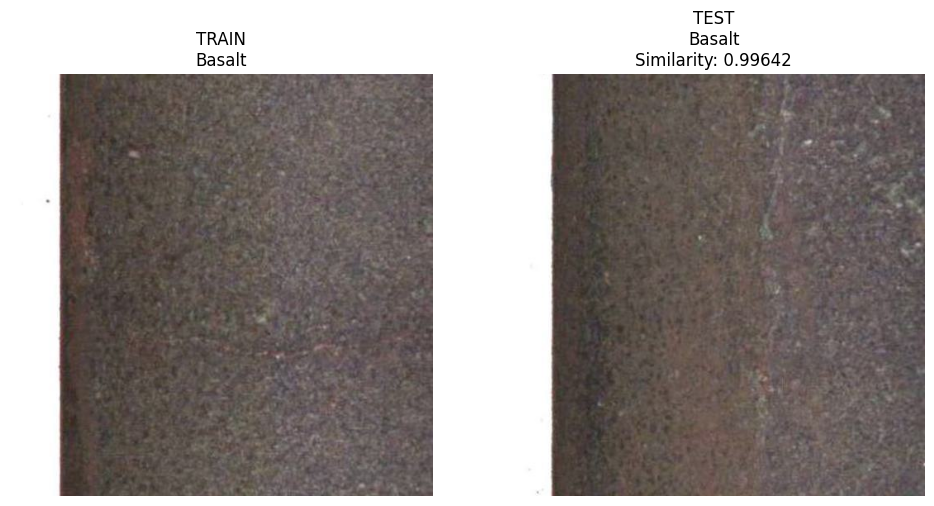

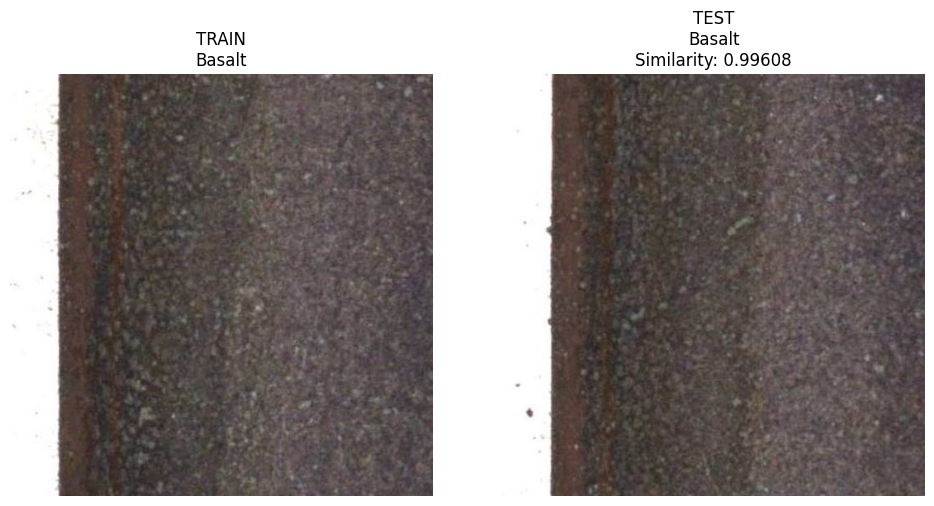

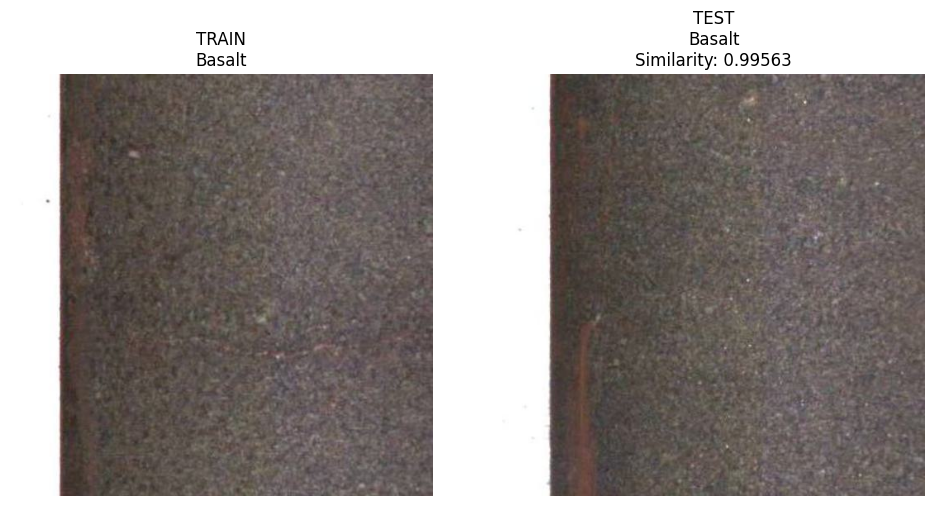

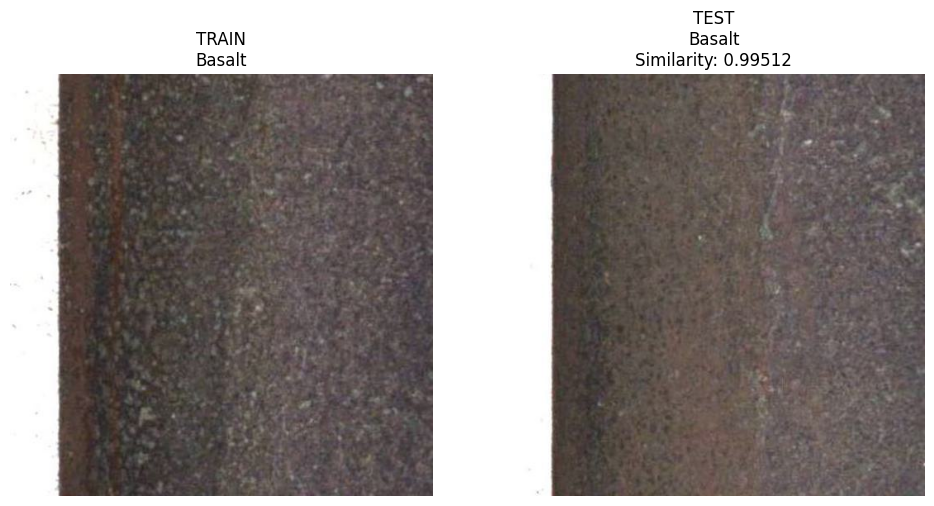

In [19]:
# Inspect all 4 high-similarity train-test pairs

pairs = train_test_sim.head(4)

for idx, row in pairs.iterrows():

    source_path = Path(row["source_image"])
    target_path = Path(row["target_image"])

    if not source_path.is_absolute():
        source_path = DATA_ROOT / source_path

    if not target_path.is_absolute():
        target_path = DATA_ROOT / target_path

    source_image = Image.open(
        source_path
    ).convert("RGB")

    target_image = Image.open(
        target_path
    ).convert("RGB")

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(source_image)
    plt.title(
        f"TRAIN\n{row['source_label']}"
    )
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(target_image)
    plt.title(
        f"TEST\n{row['target_label']}\n"
        f"Similarity: {row['similarity']:.5f}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Source: /kaggle/input/datasets/utkarshrode/geosiglip-dcid-7-lithology-dataset/kaggle_dataset/images/train/Basalt/6.Basalt_898.jpg
Target: /kaggle/input/datasets/utkarshrode/geosiglip-dcid-7-lithology-dataset/kaggle_dataset/images/test/Basalt/6.Basalt_251.jpg
Similarity: 0.9964166879653931


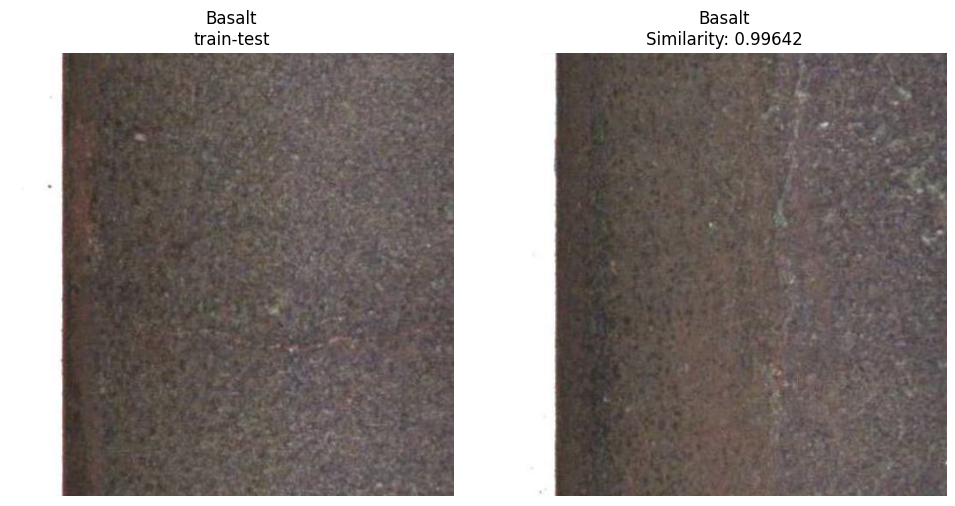

In [20]:
# Cell 19 — Visual inspection of the most suspicious pair

if len(suspicious_pairs) > 0:

    row = suspicious_pairs.iloc[0]

    source_path = Path(row["source_image"])
    target_path = Path(row["target_image"])

    # Convert relative dataset paths to absolute paths
    if not source_path.is_absolute():
        source_path = DATA_ROOT / source_path

    if not target_path.is_absolute():
        target_path = DATA_ROOT / target_path

    print("Source:", source_path)
    print("Target:", target_path)
    print("Similarity:", row["similarity"])

    if not source_path.exists():
        raise FileNotFoundError(
            f"Source image not found:\n{source_path}"
        )

    if not target_path.exists():
        raise FileNotFoundError(
            f"Target image not found:\n{target_path}"
        )

    source_image = Image.open(
        source_path
    ).convert("RGB")

    target_image = Image.open(
        target_path
    ).convert("RGB")

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(source_image)
    plt.title(
        f"{row['source_label']}\n"
        f"{row['split_pair']}"
    )
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(target_image)
    plt.title(
        f"{row['target_label']}\n"
        f"Similarity: {row['similarity']:.5f}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

else:

    print(
        "No suspicious pair to display."
    )

In [21]:
print("=" * 60)
print("TEST SET INTEGRITY SUMMARY")
print("=" * 60)

print(
    "Total test images:",
    len(test_df)
)

print(
    "Unique SHA-256 hashes:",
    test_df["sha256"].nunique()
)

print(
    "Duplicate test files:",
    len(test_df)
    - test_df["sha256"].nunique()
)

print(
    "Unique image paths:",
    test_df["resolved_path"].nunique()
)

print("\nClass counts:")

display(
    test_df["label"]
    .value_counts()
    .sort_index()
)

TEST SET INTEGRITY SUMMARY
Total test images: 1750
Unique SHA-256 hashes: 1750
Duplicate test files: 0
Unique image paths: 1750

Class counts:


label
Basalt             250
Granite            250
Gray siltstone     250
Light sandstone    250
Marble             250
Mudstone           250
Red sandstone      250
Name: count, dtype: int64

In [22]:
REPORT_DIR = Path(
    "/kaggle/working/geosiglip-robustness"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Save split manifests with hashes
train_df.to_csv(
    REPORT_DIR / "train_with_hashes.csv",
    index=False
)

val_df.to_csv(
    REPORT_DIR / "validation_with_hashes.csv",
    index=False
)

test_df.to_csv(
    REPORT_DIR / "test_with_hashes.csv",
    index=False
)


# Save duplicate report
duplicate_df.to_csv(
    REPORT_DIR / "exact_cross_split_duplicates.csv",
    index=False
)


# Save similarity reports
train_val_sim.to_csv(
    REPORT_DIR / "train_validation_similarity.csv",
    index=False
)

train_test_sim.to_csv(
    REPORT_DIR / "train_test_similarity.csv",
    index=False
)

val_test_sim.to_csv(
    REPORT_DIR / "validation_test_similarity.csv",
    index=False
)

print(
    "Reports saved to:"
)

print(REPORT_DIR)

Reports saved to:
/kaggle/working/geosiglip-robustness


In [23]:
print("=" * 75)
print("GEOSIGLIP — ROBUSTNESS / DATA INTEGRITY REPORT")
print("=" * 75)

print("\nDATASET")
print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print("\nPATH OVERLAP")

print(
    "Train-Val:",
    len(train_val)
)

print(
    "Train-Test:",
    len(train_test)
)

print(
    "Val-Test:",
    len(val_test)
)

print("\nEXACT DUPLICATES")

print(
    "Cross-split duplicate hashes:",
    len(duplicate_df)
)

print(
    "Conflicting duplicate labels:",
    len(conflicting_hashes)
)

print("\nHIGH VISUAL SIMILARITY")

print(
    "Train-Val pairs:",
    len(train_val_sim)
)

print(
    "Train-Test pairs:",
    len(train_test_sim)
)

print(
    "Val-Test pairs:",
    len(val_test_sim)
)

print("\nRESULT")

if (
    len(duplicate_df) == 0
    and len(conflicting_hashes) == 0
):

    print(
        "No exact cross-split duplicates detected."
    )

else:

    print(
        "Potential split leakage detected."
    )

print(
    "\nRobustness analysis complete."
)

print(
    "Saved reports:",
    REPORT_DIR
)

GEOSIGLIP — ROBUSTNESS / DATA INTEGRITY REPORT

DATASET
Train: 2450
Validation: 1050
Test: 1750

PATH OVERLAP
Train-Val: 0
Train-Test: 0
Val-Test: 0

EXACT DUPLICATES
Cross-split duplicate hashes: 0
Conflicting duplicate labels: 0

HIGH VISUAL SIMILARITY
Train-Val pairs: 0
Train-Test pairs: 4
Val-Test pairs: 0

RESULT
No exact cross-split duplicates detected.

Robustness analysis complete.
Saved reports: /kaggle/working/geosiglip-robustness


# Notebook 05 — Robustness Analysis Complete

This notebook verifies the integrity of the GeoSigLIP DCID-7 train, validation, and test splits.

The analysis includes:

- Exact file-path overlap across splits
- SHA-256 image duplicate detection
- Duplicate-label consistency checks
- Filename/stem overlap analysis
- High visual-similarity screening across splits
- Manual inspection of the most suspicious image pairs

The 1,750-image test set remains untouched for model training and model selection.

Final model performance is reported separately in Notebook 04.